# 02 — Autoscaling Capacity Planning Simulator

This notebook accompanies `01-production-challenge-scaling-and-reliability.md`.

It's a small, pure-Python/numpy simulator (no external services, no cloud credentials) that answers
the capacity-planning question underlying both the Azure App Service and AWS ECS Fargate scaling
models described in that chapter: **given a target requests/sec and a per-request cost, how many
application instances (App Service instances, or ECS Fargate tasks) do we need to hit a P95 latency
SLA?** — and how does that requirement change across a realistic daily traffic curve with a
business-hours peak (the same shape referenced in Chapter 04 for the Sagemaker scale-to-zero
tradeoff).

## 1. A simple queueing-based capacity model

We model each application instance (App Service instance / ECS Fargate task) as a single-server
queue that can process requests at some average rate, and use a standard result from queueing
theory (M/M/c-style approximation) to estimate P95 latency as a function of *utilization*
(offered load / total capacity). This is a simplification of real-world behavior (real services
aren't perfectly Markovian, and an LLM-backed request has highly variable service time — waiting on
a downstream Azure OpenAI/Sagemaker call dominates its latency), but it captures the qualitative
shape that matters for capacity planning: **latency stays low and roughly flat until utilization
gets close to 1.0, then rises sharply** — which is exactly why naive "just react to average CPU"
autoscaling (Chapter 01's point about CPU being a poor proxy for I/O-bound LLM load) tends to
under-provision right before a latency SLA breach, not gradually degrade ahead of it.

In [1]:
import numpy as np

def p95_latency_multiplier(utilization: float) -> float:
    """Approximates how much P95 latency inflates relative to the baseline (unloaded) per-request
    latency, as a function of utilization (0 to just under 1). Uses a standard queueing-delay-style
    curve: multiplier = 1 / (1 - utilization), clipped to avoid divide-by-zero, then mapped onto a
    P95-flavored inflation (P95 sits further out on the tail than the mean, so we apply a mild
    extra convexity exponent).
    """
    u = np.clip(utilization, 0.0, 0.995)
    mean_multiplier = 1.0 / (1.0 - u)
    p95_multiplier = mean_multiplier ** 1.6   # P95 degrades faster than the mean as u -> 1
    return p95_multiplier


def required_instances(target_rps: float, per_instance_capacity_rps: float,
                        baseline_latency_s: float, p95_sla_s: float,
                        max_utilization_search: float = 0.99) -> tuple[int, float]:
    """Returns (instances_needed, utilization_at_that_count) to keep P95 latency under the SLA at
    the given target request rate, given each instance can sustainably handle
    `per_instance_capacity_rps` requests/sec at that P95 quality.
    """
    instances = 1
    while True:
        total_capacity = instances * per_instance_capacity_rps
        utilization = target_rps / total_capacity
        if utilization < max_utilization_search:
            p95 = baseline_latency_s * p95_latency_multiplier(utilization)
            if p95 <= p95_sla_s:
                return instances, utilization
        instances += 1
        if instances > 10_000:
            raise RuntimeError("Could not find a feasible instance count -- check inputs")


# Sanity check against a simple scenario
instances, util = required_instances(
    target_rps=50, per_instance_capacity_rps=8, baseline_latency_s=0.8, p95_sla_s=2.5)
print(f"To serve 50 req/s at an 8 req/s/instance capacity, need {instances} instances "
      f"(utilization {util:.0%}) to hold P95 <= 2.5s")

To serve 50 req/s at an 8 req/s/instance capacity, need 13 instances (utilization 48%) to hold P95 <= 2.5s


## 2. A synthetic daily traffic curve

We model a business-hours-weighted daily traffic curve: low overnight traffic, a ramp-up in the
morning, a midday peak, a smaller afternoon peak, and a wind-down in the evening — the shape you'd
plausibly see for an internal banking assistant (Course 1) or a pharma content-review platform
(Course 11) used primarily during business hours in one or two dominant time zones. We express
traffic as requests/sec at each hour of a 24-hour day.

In [2]:
def synthetic_daily_traffic_curve(peak_rps=60.0, off_peak_rps=4.0):
    """Returns an array of 24 average requests/sec values, one per hour (0 = midnight), shaped like
    a business-hours workload with a mid-morning ramp, a midday peak, a smaller early-afternoon
    secondary peak, and an evening wind-down.
    """
    hours = np.arange(24)
    # Two overlapping gaussian-shaped bumps: one centered late morning, one centered mid-afternoon.
    morning_bump = np.exp(-0.5 * ((hours - 10.5) / 2.2) ** 2)
    afternoon_bump = np.exp(-0.5 * ((hours - 14.5) / 2.8) ** 2)
    shape = 0.65 * morning_bump + 0.55 * afternoon_bump
    shape = shape / shape.max()  # normalize to [0, 1]
    traffic = off_peak_rps + shape * (peak_rps - off_peak_rps)
    return hours, traffic


hours, traffic_rps = synthetic_daily_traffic_curve(peak_rps=60.0, off_peak_rps=4.0)
for h, r in zip(hours, traffic_rps):
    bar = "#" * int(r)
    print(f"{h:02d}:00  {r:5.1f} req/s  {bar}")

00:00    4.0 req/s  ####
01:00    4.0 req/s  ####
02:00    4.0 req/s  ####
03:00    4.1 req/s  ####
04:00    4.6 req/s  ####
05:00    5.9 req/s  #####
06:00    9.4 req/s  #########
07:00   16.6 req/s  ################
08:00   27.9 req/s  ###########################
09:00   41.6 req/s  #########################################
10:00   53.6 req/s  #####################################################
11:00   60.0 req/s  ############################################################
12:00   59.9 req/s  ###########################################################
13:00   55.7 req/s  #######################################################
14:00   49.8 req/s  #################################################
15:00   43.3 req/s  ###########################################
16:00   35.9 req/s  ###################################
17:00   27.9 req/s  ###########################
18:00   20.1 req/s  ####################
19:00   13.6 req/s  #############
20:00    9.1 req/s  #########
21:00    6.4 req/s

## 3. Required capacity across the day

Now we apply `required_instances` at every hour of the synthetic traffic curve, for both a
theoretical App Service / ECS Fargate deployment with a given per-instance capacity. This shows the
autoscaling curve a well-tuned scale-out policy should track — and makes concrete why a **fixed,
peak-sized fleet running 24/7** (no autoscaling at all) is wasteful compared to a fleet that tracks
this curve, which is the same tradeoff Chapter 04 discusses for Sagemaker endpoint
always-on-vs-scale-aware sizing, applied here to the ECS/App Service application tier.

In [3]:
PER_INSTANCE_CAPACITY_RPS = 8.0
BASELINE_LATENCY_S = 0.8
P95_SLA_S = 2.5

required_by_hour = []
for r in traffic_rps:
    n, u = required_instances(r, PER_INSTANCE_CAPACITY_RPS, BASELINE_LATENCY_S, P95_SLA_S)
    required_by_hour.append(n)
required_by_hour = np.array(required_by_hour)

peak_fixed_size = required_by_hour.max()

print(f"{'Hour':>5} {'Req/s':>7} {'Instances needed':>18} {'Fixed peak-sized fleet':>24}")
for h, r, n in zip(hours, traffic_rps, required_by_hour):
    print(f"{h:02d}:00 {r:7.1f} {n:18d} {peak_fixed_size:24d}")

instance_hours_autoscaled = required_by_hour.sum()
instance_hours_fixed = peak_fixed_size * 24
savings_pct = 100 * (1 - instance_hours_autoscaled / instance_hours_fixed)

print(f"\nTotal instance-hours/day, autoscaled to match demand: {instance_hours_autoscaled}")
print(f"Total instance-hours/day, fixed peak-sized fleet:       {instance_hours_fixed}")
print(f"Autoscaling saves approximately {savings_pct:.0f}% of instance-hours vs. a fixed peak-sized fleet")

 Hour   Req/s   Instances needed   Fixed peak-sized fleet
00:00     4.0                  1                       15
01:00     4.0                  1                       15
02:00     4.0                  1                       15
03:00     4.1                  2                       15
04:00     4.6                  2                       15
05:00     5.9                  2                       15
06:00     9.4                  3                       15
07:00    16.6                  5                       15
08:00    27.9                  7                       15
09:00    41.6                 11                       15
10:00    53.6                 14                       15
11:00    60.0                 15                       15
12:00    59.9                 15                       15
13:00    55.7                 14                       15
14:00    49.8                 13                       15
15:00    43.3                 11                       15
16:00    35.9 

## 4. Plotting the curve (optional — falls back to a text summary if matplotlib is unavailable)

We plot traffic (req/s) and required instance count on twin axes across the 24-hour day, so the
scale-out/scale-in shape is visible at a glance. This is the plot you'd want next to a real
CloudWatch/Azure Monitor autoscale-activity chart when validating that a scaling policy is actually
tracking demand rather than lagging behind it.

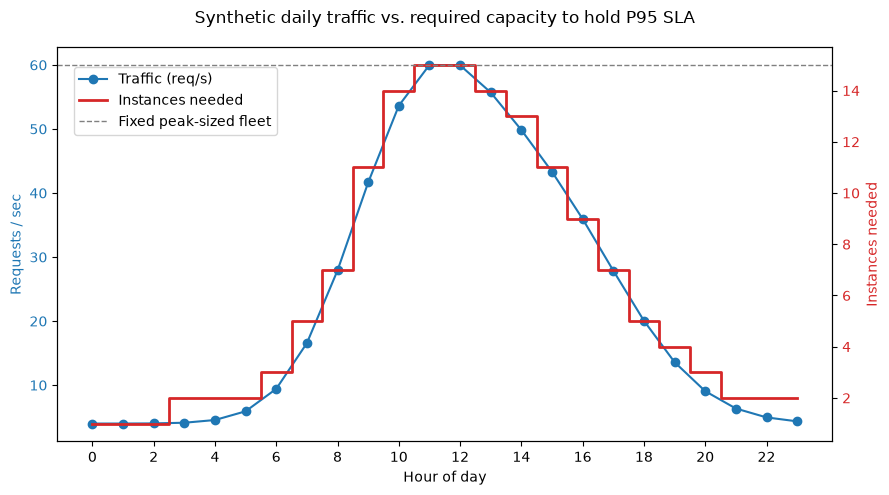

In [4]:
try:
    import matplotlib.pyplot as plt

    fig, ax1 = plt.subplots(figsize=(9, 5))

    ax1.plot(hours, traffic_rps, color="tab:blue", marker="o", label="Traffic (req/s)")
    ax1.set_xlabel("Hour of day")
    ax1.set_ylabel("Requests / sec", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    ax1.set_xticks(hours[::2])

    ax2 = ax1.twinx()
    ax2.step(hours, required_by_hour, where="mid", color="tab:red", linewidth=2,
              label="Instances needed")
    ax2.axhline(peak_fixed_size, color="gray", linestyle="--", linewidth=1,
                label="Fixed peak-sized fleet")
    ax2.set_ylabel("Instances needed", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    fig.suptitle("Synthetic daily traffic vs. required capacity to hold P95 SLA")
    fig.legend(loc="upper left", bbox_to_anchor=(0.08, 0.88))
    fig.tight_layout()
    plt.show()
except ImportError:
    print("matplotlib not available -- text summary of required instances by hour:")
    for h, n in zip(hours, required_by_hour):
        print(f"{h:02d}:00  {'#' * n} ({n})")

## 5. Takeaways this maps back to Chapter 01

- Required capacity roughly tracks the traffic curve's *shape*, but because P95 latency degrades
  convexly as utilization approaches 1.0, capacity needs to stay a comfortable margin **above**
  raw linear demand — an autoscale policy that waits until it's already at 100% utilization to add
  capacity will already have breached the SLA by the time new instances come online (and Fargate
  task startup / App Service scale-out isn't instantaneous, which this simplified model doesn't even
  account for — real headroom needs to be larger still).
- The instance-hour savings from autoscaling to match this curve versus running a fixed,
  peak-sized fleet 24/7 is the same economic argument behind Chapter 04's Sagemaker
  scale-to-zero-vs-always-on discussion — just applied to the ECS/App Service tier instead of the
  inference tier.
- A launch-day or deadline-driven traffic spike (Chapter 01's illustrative incident) is exactly a
  case where the *shape* of this curve changes suddenly and by a large multiple — which is why
  load-testing against a **projected peak**, not the historical curve alone, matters ahead of a
  known business event.